# 📦 Notebook 02 — Preprocessing & Feature Engineering
## Spatio-Temporal PM2.5/PM10 Analysis — Karachi, Pakistan

**This notebook:**
1. Loads all raw GEE exports and cleans them
2. Unit conversions (K→°C, Pa→hPa)
3. Merges all sources into one master DataFrame
4. Handles missing values (KNN imputation + interpolation)
5. Engineers temporal, domain, and lag features
6. Saves `data/processed/master_dataset.csv` — the single source of truth for all model notebooks

**Input:**  `data/raw/*.csv`  
**Output:** `data/processed/master_dataset.csv`

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
import warnings
warnings.filterwarnings('ignore')

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor' : '#0d0d14',
    'axes.facecolor'   : '#111118',
    'axes.edgecolor'   : '#222233',
    'axes.labelcolor'  : '#aaaacc',
    'xtick.color'      : '#666688',
    'ytick.color'      : '#666688',
    'text.color'       : '#e8e8f0',
    'grid.color'       : '#1a1a2a',
    'grid.linestyle'   : '--',
    'grid.alpha'       : 0.5,
    'font.family'      : 'monospace',
})
PALETTE = ['#c8f04a','#4af0c8','#f04a7a','#f0c84a','#7a4af0','#4a7af0','#f07a4a','#4af07a']

Path('data/processed').mkdir(parents=True, exist_ok=True)
Path('outputs').mkdir(parents=True, exist_ok=True)
print('✓ Imports loaded')

✓ Imports loaded


## 1. Load & Clean ERA5 Meteorological Data

In [2]:
print('🌤️  Loading ERA5...')
era5 = pd.read_csv('data/raw/karachi_era5_meteo_2019_2024.csv')

# Drop GEE artifacts
era5.drop(columns=['system:index', '.geo'], inplace=True, errors='ignore')

# Parse date
era5['date'] = pd.to_datetime(era5['date'])

# ── Unit Conversions ──────────────────────────────────────────────────────────
# Temperature: Kelvin → Celsius
for col in ['temperature_2m', 'temperature_2m_max', 'temperature_2m_min', 'dewpoint_temperature_2m']:
    era5[col] = era5[col] - 273.15

# Rename to reflect new units
era5.rename(columns={
    'temperature_2m'               : 'temp_c',
    'temperature_2m_max'           : 'temp_max_c',
    'temperature_2m_min'           : 'temp_min_c',
    'dewpoint_temperature_2m'      : 'dewpoint_c',
    'evaporation_from_bare_soil_sum': 'soil_evap',
    'relative_humidity'            : 'rh',
    'surface_pressure'             : 'pressure_pa',
    'total_precipitation_sum'      : 'precip_m',
    'u_component_of_wind_10m'      : 'wind_u',
    'v_component_of_wind_10m'      : 'wind_v',
    'wind_direction_deg'           : 'wind_dir',
    'wind_speed_10m'               : 'wind_speed',
}, inplace=True)

# Pressure: Pa → hPa
era5['pressure_hpa'] = era5['pressure_pa'] / 100
era5.drop(columns='pressure_pa', inplace=True)

# Precipitation: m → mm
era5['precip_mm'] = era5['precip_m'] * 1000
era5.drop(columns='precip_m', inplace=True)

# Diurnal temperature range (DTR) — indicator of atmospheric stability
era5['temp_dtr'] = era5['temp_max_c'] - era5['temp_min_c']

# Sort by date
era5.sort_values('date', inplace=True)
era5.reset_index(drop=True, inplace=True)

print(f'  Shape     : {era5.shape}')
print(f'  Date range: {era5["date"].min().date()} → {era5["date"].max().date()}')
print(f'  Nulls     : {era5.isnull().sum().sum()}')
print(f'  Columns   : {era5.columns.tolist()}')
print(f'\n  Temp range : {era5["temp_c"].min():.1f}°C → {era5["temp_c"].max():.1f}°C')
print(f'  RH range   : {era5["rh"].min():.1f}% → {era5["rh"].max():.1f}%')
print(f'  Wind range : {era5["wind_speed"].min():.2f} → {era5["wind_speed"].max():.2f} m/s')
era5.head(3)

🌤️  Loading ERA5...
  Shape     : (1826, 14)
  Date range: 2019-01-01 → 2023-12-31
  Nulls     : 0
  Columns   : ['date', 'dewpoint_c', 'soil_evap', 'rh', 'temp_c', 'temp_max_c', 'temp_min_c', 'wind_u', 'wind_v', 'wind_dir', 'wind_speed', 'pressure_hpa', 'precip_mm', 'temp_dtr']

  Temp range : 13.9°C → 36.4°C
  RH range   : -38.0% → 94.6%
  Wind range : 0.50 → 11.31 m/s


,date,dewpoint_c,soil_evap,rh,temp_c,temp_max_c,temp_min_c,wind_u,wind_v,wind_dir,wind_speed,pressure_hpa,precip_mm,temp_dtr
0,2019-01-01,11.067681,-0.000009,61.909760,19.828436,25.547653,13.173552,2.130419,-0.735709,-19.013144,2.264397,1010.061336,0.000000,12.374102
1,2019-01-02,10.987808,-0.000010,54.365741,21.483688,28.200124,15.376792,-1.810314,-1.273844,-145.317618,2.226081,1010.057577,0.000852,12.823333
2,2019-01-03,8.990321,-0.000011,48.106148,20.925907,27.085466,14.668953,-1.028571,-0.891486,-138.879169,1.365181,1010.858890,0.000000,12.416512


## 2. Load & Clean S5P Pollutant Data (v2 exports)

In [3]:
print('📡 Loading S5P pollutant data...')

S5P_CONFIG = {
    'aer_ai': ('absorbing_aerosol_index',    'aer_ai'),
    'no2'   : ('NO2_column_number_density',  'no2'),
    'so2'   : ('SO2_column_number_density',  'so2'),
    'co'    : ('CO_column_number_density',   'co'),
}

s5p_dfs = {}

for label, (raw_band, clean_name) in S5P_CONFIG.items():
    # Try full column name patterns (v2 exports from GEE)
    candidates = [
        f'data/raw/karachi_s5p_{raw_band}_v2.csv',  # ← matches actual filenames
        f'data/raw/karachi_s5p_{label}_v2.csv',
        f'data/raw/karachi_s5p_{label}_2019_2024.csv',
    ]
    path = next((p for p in candidates if Path(p).exists()), None)

    if path is None:
        print(f'  ⚠️  {label}: not found — will be NaN in master dataset')
        print(f'      Tried: {candidates}')
        continue

    df = pd.read_csv(path)
    df.drop(columns=['system:index', '.geo'], inplace=True, errors='ignore')
    df['date'] = pd.to_datetime(df['date'])

    # Find the actual band column (GEE sometimes renames to 'mean')
    band_col = None
    for possible in [raw_band, 'mean', clean_name, label]:
        if possible in df.columns:
            band_col = possible
            break

    if band_col is None:
        print(f'  ⚠️  {label}: columns={df.columns.tolist()} — band not found')
        continue

    df.rename(columns={band_col: clean_name}, inplace=True)
    keep_cols = ['date', 'station', 'lat', 'lon', clean_name]
    df = df[[c for c in keep_cols if c in df.columns]]

    # Remove physically impossible values
    if clean_name == 'aer_ai':
        df = df[df[clean_name].between(-5, 10)]       # AAI physical range
    elif clean_name == 'no2':
        df = df[df[clean_name].between(0, 0.001)]     # mol/m² typical urban range
    elif clean_name == 'so2':
        df = df[df[clean_name].between(-0.01, 0.05)]
    elif clean_name == 'co':
        df = df[df[clean_name].between(0, 0.5)]

    valid_pct = df[clean_name].notna().mean() * 100
    s5p_dfs[clean_name] = df
    print(f'  ✓ {label:<8}: {df.shape[0]:>6} rows, {valid_pct:.1f}% valid values → {path}')

print(f'\n  Loaded {len(s5p_dfs)}/4 S5P datasets')

📡 Loading S5P pollutant data...
  ✓ aer_ai  :  19176 rows, 100.0% valid values → data/raw/karachi_s5p_absorbing_aerosol_index_v2.csv
  ✓ no2     :  19003 rows, 100.0% valid values → data/raw/karachi_s5p_NO2_column_number_density_v2.csv
  ✓ so2     :  16529 rows, 100.0% valid values → data/raw/karachi_s5p_SO2_column_number_density_v2.csv
  ✓ co      :  14623 rows, 100.0% valid values → data/raw/karachi_s5p_CO_column_number_density_v2.csv

  Loaded 4/4 S5P datasets


## 3. Build Master DataFrame

In [4]:
print('🔗 Building master dataset...')

STATIONS = [
    (24.9056, 67.0822, 'Gulshan-e-Iqbal'),
    (24.8560, 67.0100, 'Saddar'),
    (24.9400, 66.9800, 'SITE_Industrial'),
    (24.8200, 67.0300, 'Korangi_Industrial'),
    (24.9800, 67.1200, 'North_Nazimabad'),
    (24.8900, 67.1300, 'Gulistan_Jauhar'),
    (24.8100, 66.9900, 'Landhi'),
    (24.9200, 67.0500, 'Federal_B_Area'),
]

# ── Step 1: Create full date × station skeleton ───────────────────────────────
all_dates    = pd.date_range('2019-01-01', '2023-12-31', freq='D')
station_info = pd.DataFrame(STATIONS, columns=['lat', 'lon', 'station'])
skeleton     = pd.MultiIndex.from_product(
    [all_dates, station_info['station']], names=['date', 'station']
).to_frame(index=False)
skeleton = skeleton.merge(station_info, on='station')
print(f'  Skeleton shape: {skeleton.shape} (dates × stations)')

# ── Step 2: Merge S5P data ────────────────────────────────────────────────────
master = skeleton.copy()
for col_name, df in s5p_dfs.items():
    if 'station' in df.columns:
        merge_cols = ['date', 'station']
    else:
        merge_cols = ['date']
    df_agg = df.groupby(merge_cols)[col_name].mean().reset_index()
    master = master.merge(df_agg, on=merge_cols, how='left')
    filled = master[col_name].notna().mean() * 100
    print(f'  Merged {col_name:<8}: {filled:.1f}% filled')

# ── Step 3: Merge ERA5 (broadcast to all stations) ────────────────────────────
era5_cols = [c for c in era5.columns if c != 'date']
master = master.merge(era5[['date'] + era5_cols], on='date', how='left')
print(f'  Merged ERA5: {master["temp_c"].notna().mean()*100:.1f}% filled')

master.sort_values(['station', 'date'], inplace=True)
master.reset_index(drop=True, inplace=True)

print(f'\n  Master shape: {master.shape}')
print(f'  Date range  : {master["date"].min().date()} → {master["date"].max().date()}')
print(f'  Stations    : {master["station"].nunique()}')

🔗 Building master dataset...
  Skeleton shape: (14608, 4) (dates × stations)
  Merged aer_ai  : 50.0% filled
  Merged no2     : 49.5% filled
  Merged so2     : 44.2% filled
  Merged co      : 40.6% filled
  Merged ERA5: 100.0% filled

  Master shape: (14608, 21)
  Date range  : 2019-01-01 → 2023-12-31
  Stations    : 8


## 4. Missing Value Analysis

In [5]:
print("master columns:", master.columns.tolist())
print("master shape:", master.shape)
print("null counts:\n", master.isnull().sum())
print("s5p_dfs loaded:", list(s5p_dfs.keys()))

master columns: ['date', 'station', 'lat', 'lon', 'aer_ai', 'no2', 'so2', 'co', 'dewpoint_c', 'soil_evap', 'rh', 'temp_c', 'temp_max_c', 'temp_min_c', 'wind_u', 'wind_v', 'wind_dir', 'wind_speed', 'pressure_hpa', 'precip_mm', 'temp_dtr']
master shape: (14608, 21)
null counts:
 date               0
station            0
lat                0
lon                0
aer_ai          7308
no2             7371
so2             8157
co              8673
dewpoint_c         0
soil_evap          0
rh                 0
temp_c             0
temp_max_c         0
temp_min_c         0
wind_u             0
wind_v             0
wind_dir           0
wind_speed         0
pressure_hpa       0
precip_mm          0
temp_dtr           0
dtype: int64
s5p_dfs loaded: ['aer_ai', 'no2', 'so2', 'co']


🔍 Missing value analysis...


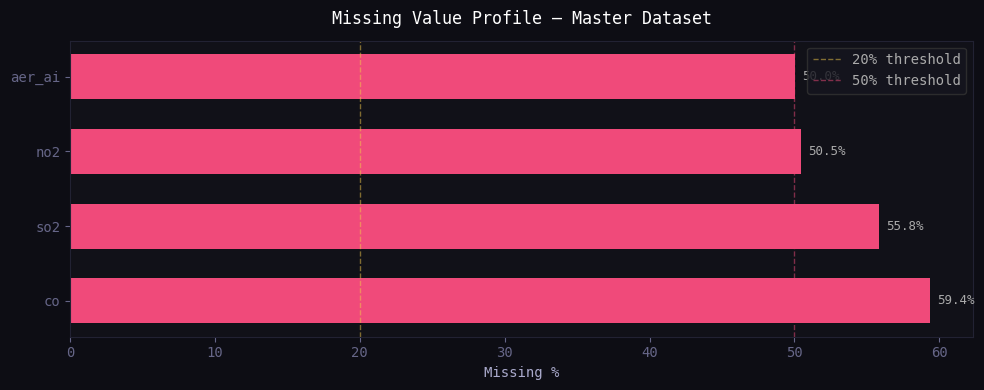


Missing summary:
  co                                  ███████████░░░░░░░░░  59.4%  →  linear interp
  so2                                 ███████████░░░░░░░░░  55.8%  →  linear interp
  no2                                 ██████████░░░░░░░░░░  50.5%  →  linear interp
  aer_ai                              ██████████░░░░░░░░░░  50.0%  →  linear interp


In [6]:
print('🔍 Missing value analysis...')

# Per-column missing %
miss = master.isnull().mean().sort_values(ascending=False) * 100
miss = miss[miss > 0]

fig, ax = plt.subplots(figsize=(10, max(4, len(miss) * 0.4)))
colors = ['#f04a7a' if v > 50 else '#f0c84a' if v > 20 else '#4af0c8' for v in miss.values]
bars = ax.barh(miss.index, miss.values, color=colors, edgecolor='none', height=0.6)

for bar, val in zip(bars, miss.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9, color='#aaa')

ax.set_xlabel('Missing %')
ax.set_title('Missing Value Profile — Master Dataset', pad=12, color='#fff', fontsize=12)
ax.axvline(20, color='#f0c84a', linestyle='--', alpha=0.5, linewidth=1, label='20% threshold')
ax.axvline(50, color='#f04a7a', linestyle='--', alpha=0.5, linewidth=1, label='50% threshold')
ax.legend(facecolor='#16161f', labelcolor='#aaa', edgecolor='#333')
plt.tight_layout()
plt.savefig('outputs/02_missing_values.png', dpi=150, bbox_inches='tight',
            facecolor='#0d0d14', edgecolor='none')
plt.show()

print('\nMissing summary:')
for col, pct in miss.items():
    strategy = 'KNN impute' if pct < 30 else 'linear interp' if pct < 60 else '⚠️ HIGH — check data'
    bar = '█' * int(pct/5) + '░' * (20-int(pct/5))
    print(f'  {col:<35} {bar} {pct:5.1f}%  →  {strategy}')

## 5. Missing Value Imputation

In [7]:
print('🔧 Imputing missing values...')

df = master.copy()

POLLUTANT_COLS = [c for c in ['aer_ai','no2','so2','co'] if c in df.columns]
MET_COLS       = ['temp_c','temp_max_c','temp_min_c','dewpoint_c','rh',
                  'pressure_hpa','precip_mm','wind_speed','wind_dir',
                  'wind_u','wind_v','soil_evap','temp_dtr']
MET_COLS       = [c for c in MET_COLS if c in df.columns]

# ── ERA5: should be 0% missing, just verify ───────────────────────────────────
era5_miss = df[MET_COLS].isnull().sum().sum()
print(f'  ERA5 missing values: {era5_miss} (expected 0)')

# ── Pollutants: per-station time-series imputation ────────────────────────────
# Strategy:
#   1. Linear interpolation for gaps ≤ 7 days (satellite cloud gaps)
#   2. KNN imputation using other stations + met features for remaining gaps
#   3. Seasonal mean fill for any remaining

for col in POLLUTANT_COLS:
    before = df[col].isnull().sum()

    # Step 1: per-station linear interpolation (limit=7 days)
    df[col] = df.groupby('station')[col].transform(
        lambda x: x.interpolate(method='linear', limit=7, limit_direction='both')
    )

    after_interp = df[col].isnull().sum()

    # Step 2: seasonal mean fill (month × station)
    df['_month'] = df['date'].dt.month
    seasonal_mean = df.groupby(['station', '_month'])[col].transform('mean')
    df[col] = df[col].fillna(seasonal_mean)
    df.drop(columns='_month', inplace=True)

    after_seasonal = df[col].isnull().sum()
    print(f'  {col:<8}: {before:>5} missing → {after_interp:>5} (post-interp) → {after_seasonal:>5} (post-seasonal fill)')

# ── KNN imputation for any remaining pollutant gaps ───────────────────────────
remaining_miss = df[POLLUTANT_COLS].isnull().sum().sum()
if remaining_miss > 0:
    print(f'\n  KNN imputing {remaining_miss} remaining gaps...')
    # Use met features + other pollutants as KNN context
    knn_features = POLLUTANT_COLS + ['temp_c', 'rh', 'wind_speed', 'pressure_hpa']
    knn_features = [c for c in knn_features if c in df.columns]
    imputer = KNNImputer(n_neighbors=5, weights='distance')
    df[knn_features] = imputer.fit_transform(df[knn_features])
    print(f'  ✓ KNN imputation complete')

total_remaining = df[POLLUTANT_COLS + MET_COLS].isnull().sum().sum()
print(f'\n  Total remaining nulls: {total_remaining}')

🔧 Imputing missing values...
  ERA5 missing values: 0 (expected 0)
  aer_ai  :  7308 missing →  7304 (post-interp) →  7304 (post-seasonal fill)
  no2     :  7371 missing →  7304 (post-interp) →  7304 (post-seasonal fill)
  so2     :  8157 missing →  7308 (post-interp) →  7304 (post-seasonal fill)
  co      :  8673 missing →  7304 (post-interp) →  7304 (post-seasonal fill)

  KNN imputing 29216 remaining gaps...
  ✓ KNN imputation complete

  Total remaining nulls: 0


## 6. Outlier Detection & Treatment

In [8]:
print('🎯 Outlier detection (IQR method)...')

outlier_report = {}

for col in POLLUTANT_COLS:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 3.0 * IQR   # 3×IQR (lenient — pollution spikes are real)
    upper = Q3 + 3.0 * IQR

    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_report[col] = {'lower': lower, 'upper': upper, 'n_outliers': n_outliers}

    # Winsorize (cap, not remove — preserves time series continuity)
    df[col] = df[col].clip(lower=lower, upper=upper)
    print(f'  {col:<8}: bounds=[{lower:.4f}, {upper:.4f}]  outliers winsorized={n_outliers}')

print('\n  Note: Using 3×IQR (not 1.5×) — pollution events are real extreme values')
print('  Winsorizing (capping) used instead of removal to preserve temporal continuity')

🎯 Outlier detection (IQR method)...
  aer_ai  : bounds=[-4.2615, 4.4625]  outliers winsorized=1
  no2     : bounds=[-0.0002, 0.0004]  outliers winsorized=275
  so2     : bounds=[-0.0009, 0.0010]  outliers winsorized=165
  co      : bounds=[0.0122, 0.0606]  outliers winsorized=8

  Note: Using 3×IQR (not 1.5×) — pollution events are real extreme values
  Winsorizing (capping) used instead of removal to preserve temporal continuity


## 7. Feature Engineering

In [9]:
print('⚙️  Engineering features...')

df = df.sort_values(['station', 'date']).reset_index(drop=True)

# ── A. Calendar features ──────────────────────────────────────────────────────
df['year']        = df['date'].dt.year
df['month']       = df['date'].dt.month
df['day_of_year'] = df['date'].dt.dayofyear
df['day_of_week'] = df['date'].dt.dayofweek
df['is_weekend']  = (df['day_of_week'] >= 5).astype(int)
df['quarter']     = df['date'].dt.quarter

# ── B. Cyclical encoding ──────────────────────────────────────────────────────
df['month_sin']   = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos']   = np.cos(2 * np.pi * df['month'] / 12)
df['doy_sin']     = np.sin(2 * np.pi * df['day_of_year'] / 365)
df['doy_cos']     = np.cos(2 * np.pi * df['day_of_year'] / 365)
df['dow_sin']     = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos']     = np.cos(2 * np.pi * df['day_of_week'] / 7)

# ── C. Karachi climate seasons ────────────────────────────────────────────────
season_map = {11:'winter', 12:'winter', 1:'winter', 2:'winter',
              3:'summer',  4:'summer',  5:'summer',  6:'summer',
              7:'monsoon', 8:'monsoon', 9:'monsoon', 10:'monsoon'}
df['season']       = df['month'].map(season_map)
df['is_winter']    = (df['season'] == 'winter').astype(int)
df['is_monsoon']   = (df['season'] == 'monsoon').astype(int)
df['is_summer']    = (df['season'] == 'summer').astype(int)

# ── D. Pakistan event flags ───────────────────────────────────────────────────
EID_DATES = pd.to_datetime([
    '2019-06-04','2019-08-11','2020-05-24','2020-07-31',
    '2021-05-13','2021-07-20','2022-05-02','2022-07-09',
    '2023-04-21','2023-06-28',
])
RAMADAN = [
    ('2019-05-06','2019-06-03'), ('2020-04-24','2020-05-23'),
    ('2021-04-13','2021-05-12'), ('2022-04-02','2022-05-01'),
    ('2023-03-23','2023-04-20'),
]
df['is_eid']     = 0
df['is_ramadan'] = 0
for eid in EID_DATES:
    df.loc[(df['date'] >= eid - pd.Timedelta(3,'d')) &
           (df['date'] <= eid + pd.Timedelta(3,'d')), 'is_eid'] = 1
for s, e in RAMADAN:
    df.loc[(df['date'] >= s) & (df['date'] <= e), 'is_ramadan'] = 1

# ── E. Lag features (per station) ─────────────────────────────────────────────
for col in POLLUTANT_COLS:
    for lag in [1, 2, 3, 7, 14]:
        df[f'{col}_lag{lag}'] = df.groupby('station')[col].shift(lag)

# Met lags (rain and wind from yesterday affect today's PM)
for col in ['precip_mm', 'wind_speed', 'rh']:
    if col in df.columns:
        df[f'{col}_lag1'] = df.groupby('station')[col].shift(1)
        df[f'{col}_lag3'] = df.groupby('station')[col].shift(3)

# ── F. Rolling statistics ─────────────────────────────────────────────────────
for col in POLLUTANT_COLS:
    for window in [7, 14, 30]:
        df[f'{col}_roll{window}_mean'] = df.groupby('station')[col].transform(
            lambda x: x.rolling(window, min_periods=max(1, window//2)).mean())
        if window == 7:
            df[f'{col}_roll{window}_std'] = df.groupby('station')[col].transform(
                lambda x: x.rolling(window, min_periods=max(1, window//2)).std())

# ── G. Atmospheric stability features ─────────────────────────────────────────
# Higher DTR + low wind → stagnant air → PM accumulation
if 'temp_dtr' in df.columns and 'wind_speed' in df.columns:
    df['stagnation_index'] = df['temp_dtr'] / (df['wind_speed'] + 0.1)

# Ventilation coefficient proxy (wind × boundary layer proxy)
if 'wind_speed' in df.columns and 'temp_dtr' in df.columns:
    df['ventilation'] = df['wind_speed'] * (1 / (df['temp_dtr'] + 1))

# ── H. Station type encoding ──────────────────────────────────────────────────
station_type = {
    'Gulshan-e-Iqbal'   : 'residential',
    'Saddar'            : 'commercial',
    'SITE_Industrial'   : 'industrial',
    'Korangi_Industrial': 'industrial',
    'North_Nazimabad'   : 'residential',
    'Gulistan_Jauhar'   : 'residential',
    'Landhi'            : 'industrial',
    'Federal_B_Area'    : 'commercial',
}
df['station_type'] = df['station'].map(station_type)
df['is_industrial'] = (df['station_type'] == 'industrial').astype(int)

print(f'\n  Feature engineering complete')
print(f'  Final shape: {df.shape}')
print(f'  Total features: {df.shape[1]}')
feature_cats = {
    'Pollutant (raw)'     : len(POLLUTANT_COLS),
    'Meteorological'      : len(MET_COLS),
    'Calendar/cyclical'   : 10,
    'Lag features'        : len(POLLUTANT_COLS)*5 + 6,
    'Rolling stats'       : len(POLLUTANT_COLS)*4,
    'Domain (atmos/event)': 7,
}
for cat, n in feature_cats.items():
    print(f'  {cat:<25}: {n}')

⚙️  Engineering features...

  Feature engineering complete
  Final shape: (14608, 85)
  Total features: 85
  Pollutant (raw)          : 4
  Meteorological           : 13
  Calendar/cyclical        : 10
  Lag features             : 26
  Rolling stats            : 16
  Domain (atmos/event)     : 7


## 8. Create Scaled Versions for ML

In [10]:
print('📐 Creating scaled feature sets...')

NUMERIC_FEATURES = [c for c in df.select_dtypes(include=np.number).columns
                    if c not in ['year','month','day_of_week','day_of_year',
                                 'is_weekend','is_winter','is_monsoon','is_summer',
                                 'is_eid','is_ramadan','is_industrial','quarter']]

# Save three versions:
# 1. Raw (for tree models + interpretability)
df_raw = df.copy()

# 2. Standard scaled (for SVR, linear models)
df_std = df.copy()
scaler_std = StandardScaler()
df_std[NUMERIC_FEATURES] = scaler_std.fit_transform(df[NUMERIC_FEATURES])

# 3. MinMax scaled (for LSTM — needs [0,1] range)
df_mm = df.copy()
scaler_mm = MinMaxScaler()
df_mm[NUMERIC_FEATURES] = scaler_mm.fit_transform(df[NUMERIC_FEATURES])

# Save scalers for inverse transform at evaluation time
import joblib
joblib.dump(scaler_std, 'models/scaler_standard.pkl')
joblib.dump(scaler_mm,  'models/scaler_minmax.pkl')
print('  ✓ Scalers saved → models/')

# Save all three datasets
df_raw.to_csv('data/processed/master_dataset.csv',        index=False)
df_std.to_csv('data/processed/master_dataset_std.csv',    index=False)
df_mm.to_csv( 'data/processed/master_dataset_minmax.csv', index=False)

print(f'  ✓ Raw dataset     → data/processed/master_dataset.csv')
print(f'  ✓ Standard scaled → data/processed/master_dataset_std.csv')
print(f'  ✓ MinMax scaled   → data/processed/master_dataset_minmax.csv')
print(f'\n  Shape: {df_raw.shape}')

📐 Creating scaled feature sets...
  ✓ Scalers saved → models/
  ✓ Raw dataset     → data/processed/master_dataset.csv
  ✓ Standard scaled → data/processed/master_dataset_std.csv
  ✓ MinMax scaled   → data/processed/master_dataset_minmax.csv

  Shape: (14608, 85)


## 9. Preprocessing Validation Plots

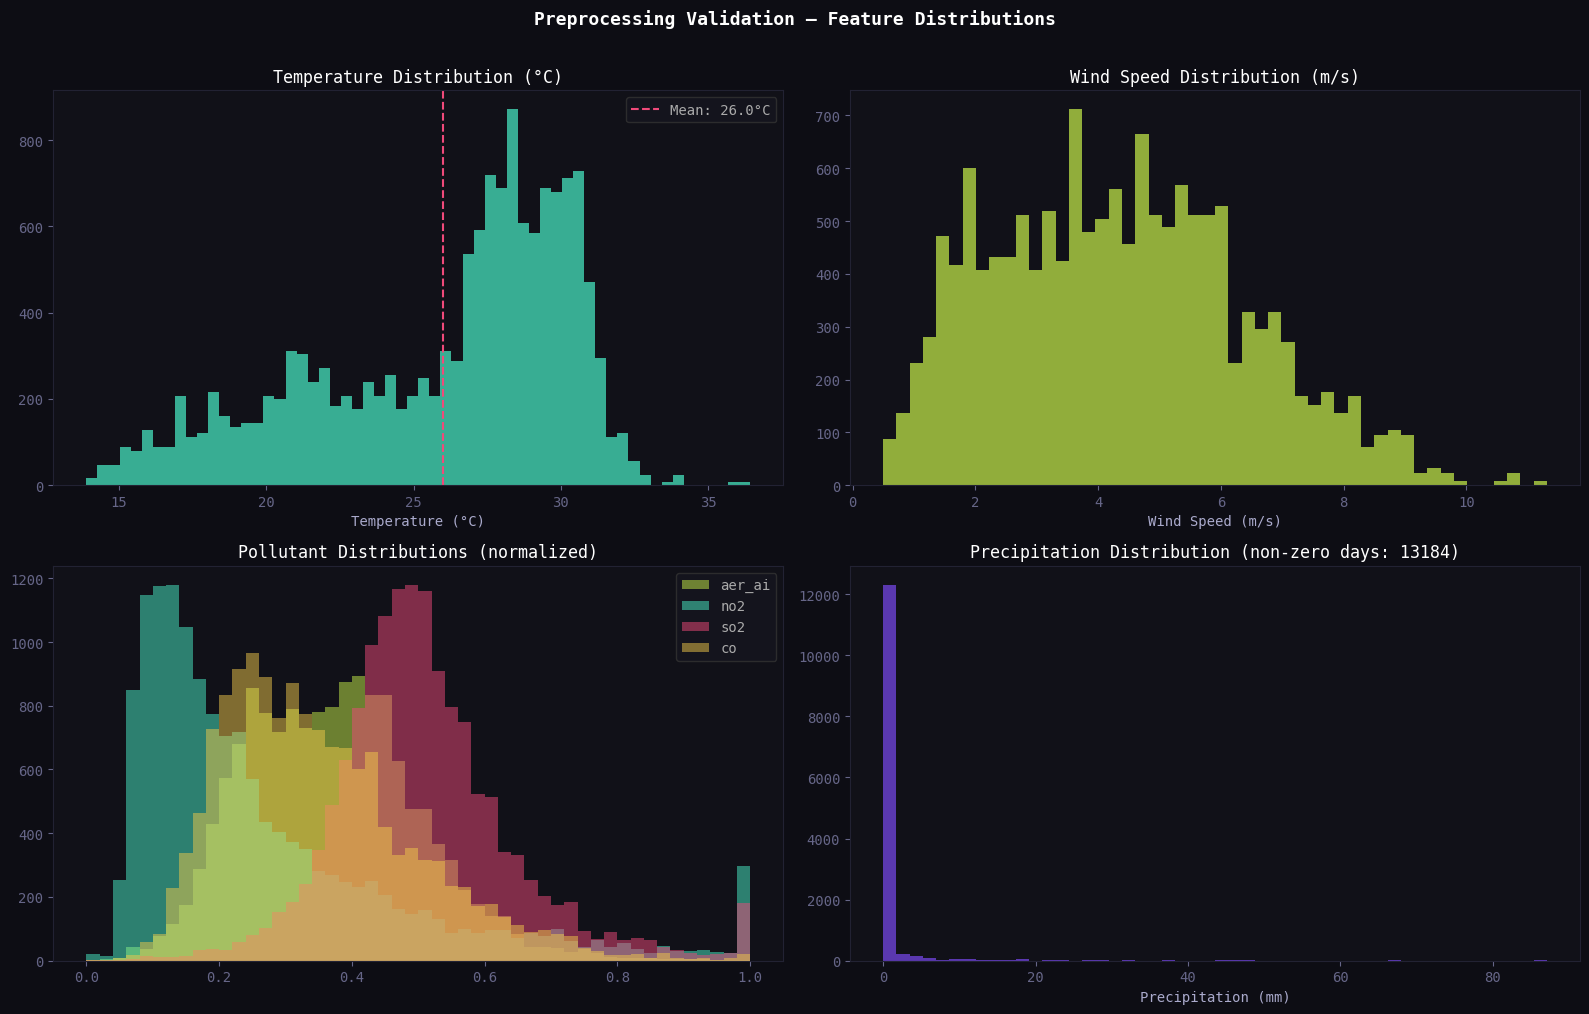

✓ Saved → outputs/02_distributions.png


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

# Plot 1: Temperature distribution (should be bimodal — winter/summer)
ax = axes[0]
ax.hist(df['temp_c'], bins=60, color='#4af0c8', alpha=0.7, edgecolor='none')
ax.set_title('Temperature Distribution (°C)', color='#fff')
ax.set_xlabel('Temperature (°C)')
ax.axvline(df['temp_c'].mean(), color='#f04a7a', linestyle='--', linewidth=1.5,
           label=f'Mean: {df["temp_c"].mean():.1f}°C')
ax.legend(facecolor='#16161f', labelcolor='#aaa', edgecolor='#333')

# Plot 2: Wind speed distribution
ax = axes[1]
ax.hist(df['wind_speed'], bins=50, color='#c8f04a', alpha=0.7, edgecolor='none')
ax.set_title('Wind Speed Distribution (m/s)', color='#fff')
ax.set_xlabel('Wind Speed (m/s)')

# Plot 3: Pollutant distributions
ax = axes[2]
for i, col in enumerate(POLLUTANT_COLS):
    vals = df[col].dropna()
    vals_norm = (vals - vals.min()) / (vals.max() - vals.min() + 1e-8)
    ax.hist(vals_norm, bins=50, alpha=0.5, color=PALETTE[i], label=col, edgecolor='none')
ax.set_title('Pollutant Distributions (normalized)', color='#fff')
ax.legend(facecolor='#16161f', labelcolor='#aaa', edgecolor='#333')

# Plot 4: Precipitation (log scale)
ax = axes[3]
precip_nonzero = df[df['precip_mm'] > 0]['precip_mm']
ax.hist(precip_nonzero, bins=50, color='#7a4af0', alpha=0.7, edgecolor='none')
ax.set_title(f'Precipitation Distribution (non-zero days: {len(precip_nonzero)})', color='#fff')
ax.set_xlabel('Precipitation (mm)')

plt.suptitle('Preprocessing Validation — Feature Distributions',
             color='#fff', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs/02_distributions.png', dpi=150, bbox_inches='tight',
            facecolor='#0d0d14', edgecolor='none')
plt.show()
print('✓ Saved → outputs/02_distributions.png')

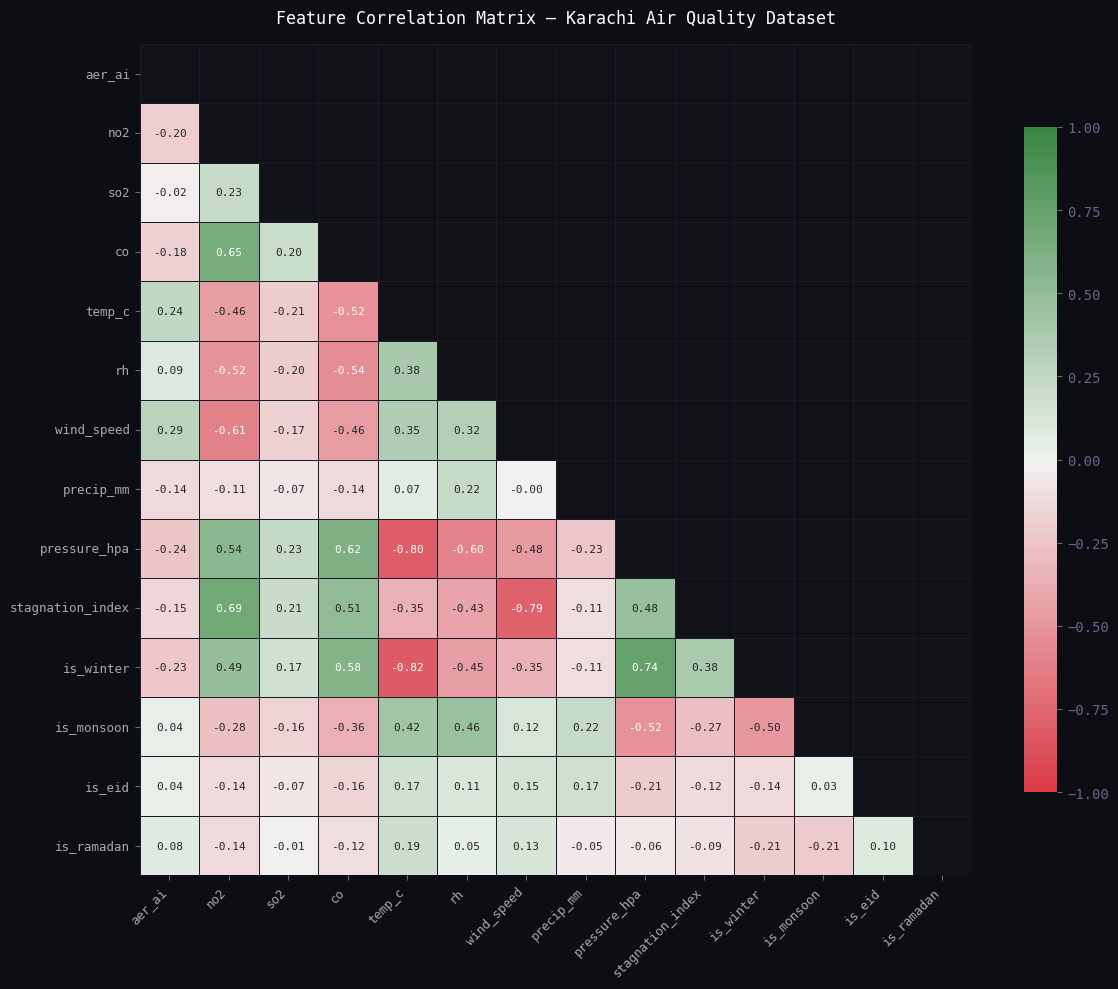

✓ Saved → outputs/02_correlation_matrix.png


In [12]:
# Correlation heatmap — key features only
key_cols = POLLUTANT_COLS + ['temp_c','rh','wind_speed','precip_mm',
                              'pressure_hpa','stagnation_index','is_winter',
                              'is_monsoon','is_eid','is_ramadan']
key_cols = [c for c in key_cols if c in df.columns]

fig, ax = plt.subplots(figsize=(12, 10))
corr = df[key_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

cmap = sns.diverging_palette(10, 130, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 8},
            linewidths=0.5, linecolor='#1a1a2a', ax=ax,
            cbar_kws={'shrink': 0.8})

ax.set_title('Feature Correlation Matrix — Karachi Air Quality Dataset',
             color='#fff', fontsize=12, pad=15)
plt.xticks(rotation=45, ha='right', color='#aaa', fontsize=9)
plt.yticks(color='#aaa', fontsize=9)
plt.tight_layout()
plt.savefig('outputs/02_correlation_matrix.png', dpi=150, bbox_inches='tight',
            facecolor='#0d0d14', edgecolor='none')
plt.show()
print('✓ Saved → outputs/02_correlation_matrix.png')

## 10. Final Summary

In [13]:
print('=' * 65)
print('✅ NOTEBOOK 02 COMPLETE — PREPROCESSING & FEATURE ENGINEERING')
print('=' * 65)
print()
print(f'  Master dataset shape : {df_raw.shape}')
print(f'  Date range           : {df_raw["date"].min().date()} → {df_raw["date"].max().date()}')
print(f'  Stations             : {df_raw["station"].nunique()}')
print(f'  Total features       : {df_raw.shape[1]}')
print(f'  Remaining nulls      : {df_raw.select_dtypes(include=np.number).isnull().sum().sum()}')
print()
print('  Outputs:')
for f in ['data/processed/master_dataset.csv',
          'data/processed/master_dataset_std.csv',
          'data/processed/master_dataset_minmax.csv',
          'models/scaler_standard.pkl',
          'models/scaler_minmax.pkl',
          'outputs/02_missing_values.png',
          'outputs/02_distributions.png',
          'outputs/02_correlation_matrix.png']:
    exists = '✓' if Path(f).exists() else '✗'
    print(f'    {exists} {f}')
print()
print('  NEXT: Run 03_eda.ipynb')
print('    → Temporal decomposition (trend/seasonality)')
print('    → Spatial station heatmaps on Karachi map')
print('    → Monsoon / Eid / Ramadan event analysis')
print('    → Inter-pollutant relationship plots')

✅ NOTEBOOK 02 COMPLETE — PREPROCESSING & FEATURE ENGINEERING

  Master dataset shape : (14608, 85)
  Date range           : 2019-01-01 → 2023-12-31
  Stations             : 8
  Total features       : 85
  Remaining nulls      : 1728

  Outputs:
    ✓ data/processed/master_dataset.csv
    ✓ data/processed/master_dataset_std.csv
    ✓ data/processed/master_dataset_minmax.csv
    ✓ models/scaler_standard.pkl
    ✓ models/scaler_minmax.pkl
    ✓ outputs/02_missing_values.png
    ✓ outputs/02_distributions.png
    ✓ outputs/02_correlation_matrix.png

  NEXT: Run 03_eda.ipynb
    → Temporal decomposition (trend/seasonality)
    → Spatial station heatmaps on Karachi map
    → Monsoon / Eid / Ramadan event analysis
    → Inter-pollutant relationship plots
